In [ ]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from srm import catalog

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

from srm.downscaling_utils import rechunk

BUCKET = "carbonplan-srm"
REGION = "us-west-2"
STORE_PATH = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.11.0"


def _open_group(repo, branch, group):
    session = repo.readonly_session(branch=branch)
    return xr.open_dataset(session.store, engine="zarr", group=group, chunks={})


def load_downscaling_store(
    scenario,
    ens,
    variables=("tas", "pr", "rsds", "hurs", "tasmin", "tasmax"),
    path=STORE_PATH,
    branch=BRANCH,
    coarse=False,
):
    """Open every variable for a scenario/ensemble member and merge into one Dataset."""
    prefix = path.replace(f"s3://{BUCKET}/", "").strip("/")
    storage = icechunk.s3_storage(bucket=BUCKET, prefix=prefix, anonymous=True, region=REGION)
    repo = icechunk.Repository.open(storage)

    stem = f"debiased_coarse/{scenario}" if coarse else scenario
    das = []
    for var in variables:
        group = f"{stem}/{var}/{ens}"
        da = _open_group(repo, branch, group)[var].drop_vars("dayofyear", errors="ignore")
        das.append(da)
    return xr.merge(das, join="outer")


g6_ds = load_downscaling_store("g6_1p5k", ens="003")
ssp245_ds = load_downscaling_store("ssp245", ens="008")

variables = ["tas", "pr", "hurs", "rsds", "tasmin", "tasmax"]

SCENARIO_GROUPS = {
    "historical": "historical",
    "SSP245": "ssp245",
    "G6-1.5K": "g6_1p5k",
}

gcm = "CESM2-WACCM"

raw_ssp_fut = (
    catalog.get(gcm)
    .to_xarray(group=SCENARIO_GROUPS["SSP245"])[variables]
    .sel(ensemble_member="008")
)

raw_g6_fut = (
    catalog.get(gcm)
    .to_xarray(group=SCENARIO_GROUPS["G6-1.5K"])[variables]
    .sel(ensemble_member="003")
)

In [77]:
testing_period = slice("2035-01-01", "2069-12-31")

g6_ds = g6_ds.sel(time=testing_period)
ssp245_ds = ssp245_ds.sel(time=testing_period)
raw_ssp_fut = raw_ssp_fut.sel(time=testing_period)
raw_g6_fut = raw_g6_fut.sel(time=testing_period)

In [78]:
def fine_to_coarse(ds_fine, ds_coarse_grid):
    target = ds_coarse_grid.reset_coords(drop=True)
    return ds_fine.regrid.conservative(target, latitude_coord="lat")


def rechunk_ds(ds, pattern):
    return xr.merge([rechunk(ds[v], pattern=pattern) for v in variables])


# conservative regrid needs the full spatial field per timestep
fine_g6 = rechunk_ds(g6_ds, "full_space")
fine_ssp = rechunk_ds(ssp245_ds, "full_space")

coarsened_g6_ds = fine_to_coarse(fine_g6, raw_g6_fut)
coarsened_ssp_ds = fine_to_coarse(fine_ssp, raw_ssp_fut)

In [79]:
coarsened_g6_ds = coarsened_g6_ds.resample(time="YS").mean()
coarsened_ssp_ds = coarsened_ssp_ds.resample(time="YS").mean()
raw_g6_fut = raw_g6_fut.resample(time="YS").mean()
raw_ssp_fut = raw_ssp_fut.resample(time="YS").mean()

In [ ]:
locations = {
    "NYC": (40.7128, -74.0060),
    "Lima": (-12.0464, -77.0428),
    "Kampala": (0.3476, 32.5825),
    "Singapore": (1.3521, 103.8198),
    "Paris": (48.8566, 2.3522),
    "Cape Town": (-33.9249, 18.4241),
    "Bogotá": (4.7110, -74.0721),
    "Bangkok": (13.7563, 100.5018),
    "Mexico City": (19.4326, -99.1332),
}

lats = xr.DataArray([lat for lat, lon in locations.values()], dims="location")
lons = xr.DataArray([lon for lat, lon in locations.values()], dims="location")
names = xr.DataArray(list(locations.keys()), dims="location")

city_g6_ds = coarsened_g6_ds.sel(lat=lats, lon=lons, method="nearest").assign_coords(location=names)
city_ssp_ds = coarsened_ssp_ds.sel(lat=lats, lon=lons, method="nearest").assign_coords(
    location=names
)

print(city_g6_ds)
print(city_ssp_ds)

<xarray.Dataset> Size: 8kB
Dimensions:   (time: 35, location: 9)
Coordinates:
  * time      (time) datetime64[ns] 280B 2035-01-01 2036-01-01 ... 2069-01-01
  * location  (location) <U11 396B 'NYC' 'Lima' ... 'Bangkok' 'Mexico City'
    lat       (location) float64 72B 40.99 -11.78 0.4712 ... 4.241 13.66 19.32
    lon       (location) float64 72B -73.75 -77.5 32.5 ... -73.75 100.0 -98.75
Data variables:
    tas       (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    pr        (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    hurs      (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    rsds      (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    tasmin    (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    tasmax    (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
Attributes:
    units:         K
    cell_methods:  time: me

In [81]:
city_raw_g6 = raw_g6_fut.sel(lat=lats, lon=lons, method="nearest").assign_coords(location=names)
city_raw_ssp = raw_ssp_fut.sel(lat=lats, lon=lons, method="nearest").assign_coords(location=names)

print(city_raw_g6)
print(city_raw_ssp)

<xarray.Dataset> Size: 8kB
Dimensions:          (time: 35, location: 9)
Coordinates:
  * time             (time) datetime64[ns] 280B 2035-01-01 ... 2069-01-01
  * location         (location) <U11 396B 'NYC' 'Lima' ... 'Mexico City'
    lat              (location) float64 72B 40.99 -11.78 0.4712 ... 13.66 19.32
    lon              (location) float64 72B -73.75 -77.5 32.5 ... 100.0 -98.75
    ensemble_member  <U3 12B '003'
Data variables:
    tas              (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    pr               (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    hurs             (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    rsds             (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    tasmin           (time, location) float32 1kB dask.array<chunksize=(1, 9), meta=np.ndarray>
    tasmax           (time, location) float32 1kB dask.array<chunksize=(1, 9),

In [82]:
city_g6_ds = city_g6_ds.compute()
city_ssp_ds = city_ssp_ds.compute()
city_raw_g6 = city_raw_g6.compute()
city_raw_ssp = city_raw_ssp.compute()

In [83]:
city_g6_ds

<xarray.Dataset> Size: 8kB
Dimensions:   (time: 35, location: 9)
Coordinates:
  * time      (time) datetime64[ns] 280B 2035-01-01 2036-01-01 ... 2069-01-01
  * location  (location) <U11 396B 'NYC' 'Lima' ... 'Bangkok' 'Mexico City'
    lat       (location) float64 72B 40.99 -11.78 0.4712 ... 4.241 13.66 19.32
    lon       (location) float64 72B -73.75 -77.5 32.5 ... -73.75 100.0 -98.75
Data variables:
    tas       (time, location) float32 1kB 286.9 292.8 295.7 ... 302.7 288.8
    pr        (time, location) float32 1kB 4.305e-05 5.614e-06 ... 3.774e-05
    hurs      (time, location) float32 1kB 68.36 86.9 82.75 ... 70.16 64.56
    rsds      (time, location) float32 1kB 174.2 239.4 210.6 ... 226.0 245.1
    tasmin    (time, location) float32 1kB 283.0 292.0 292.2 ... 298.8 282.3
    tasmax    (time, location) float32 1kB 290.6 294.3 299.4 ... 306.7 295.0
Attributes:
    units:         K
    cell_methods:  time: mean
    short_name:    t2m
    long_name:     2 metre temperature

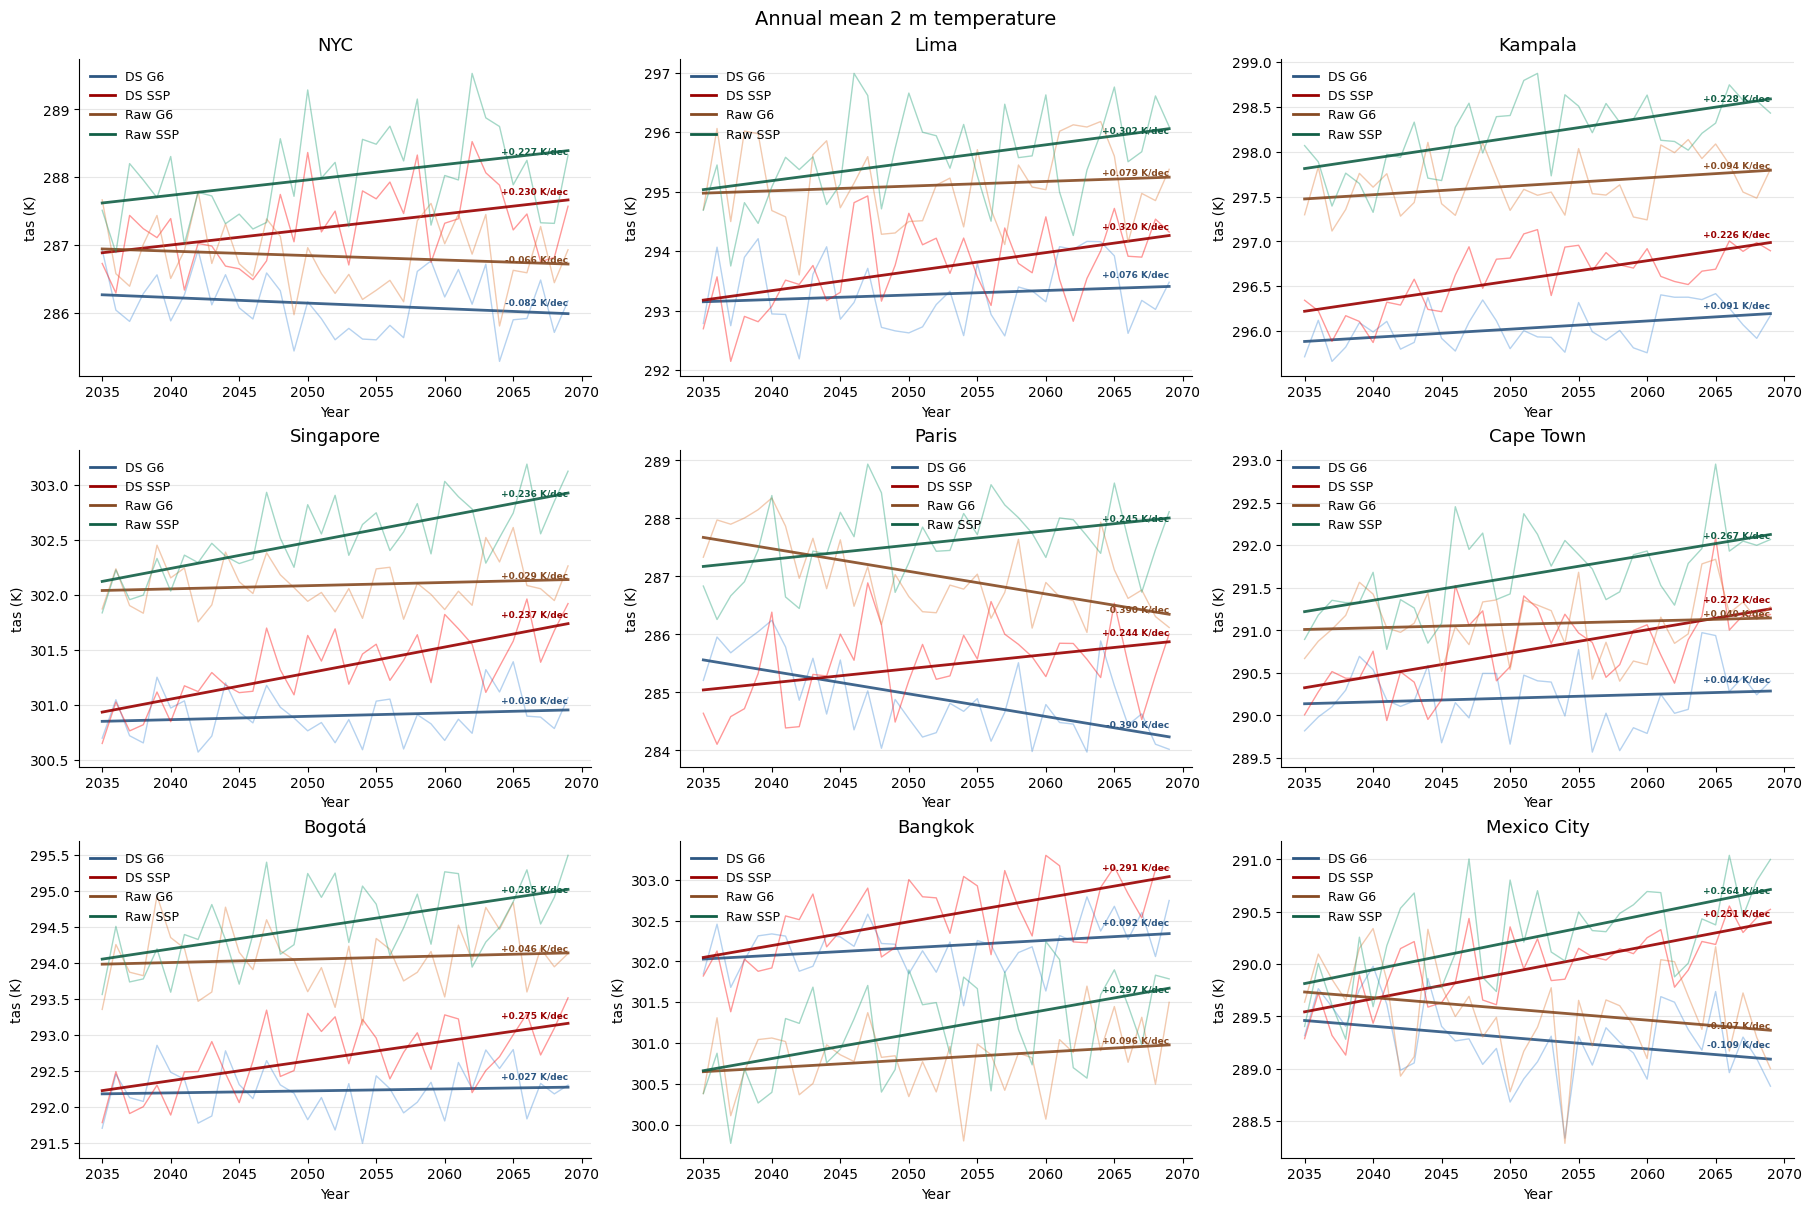

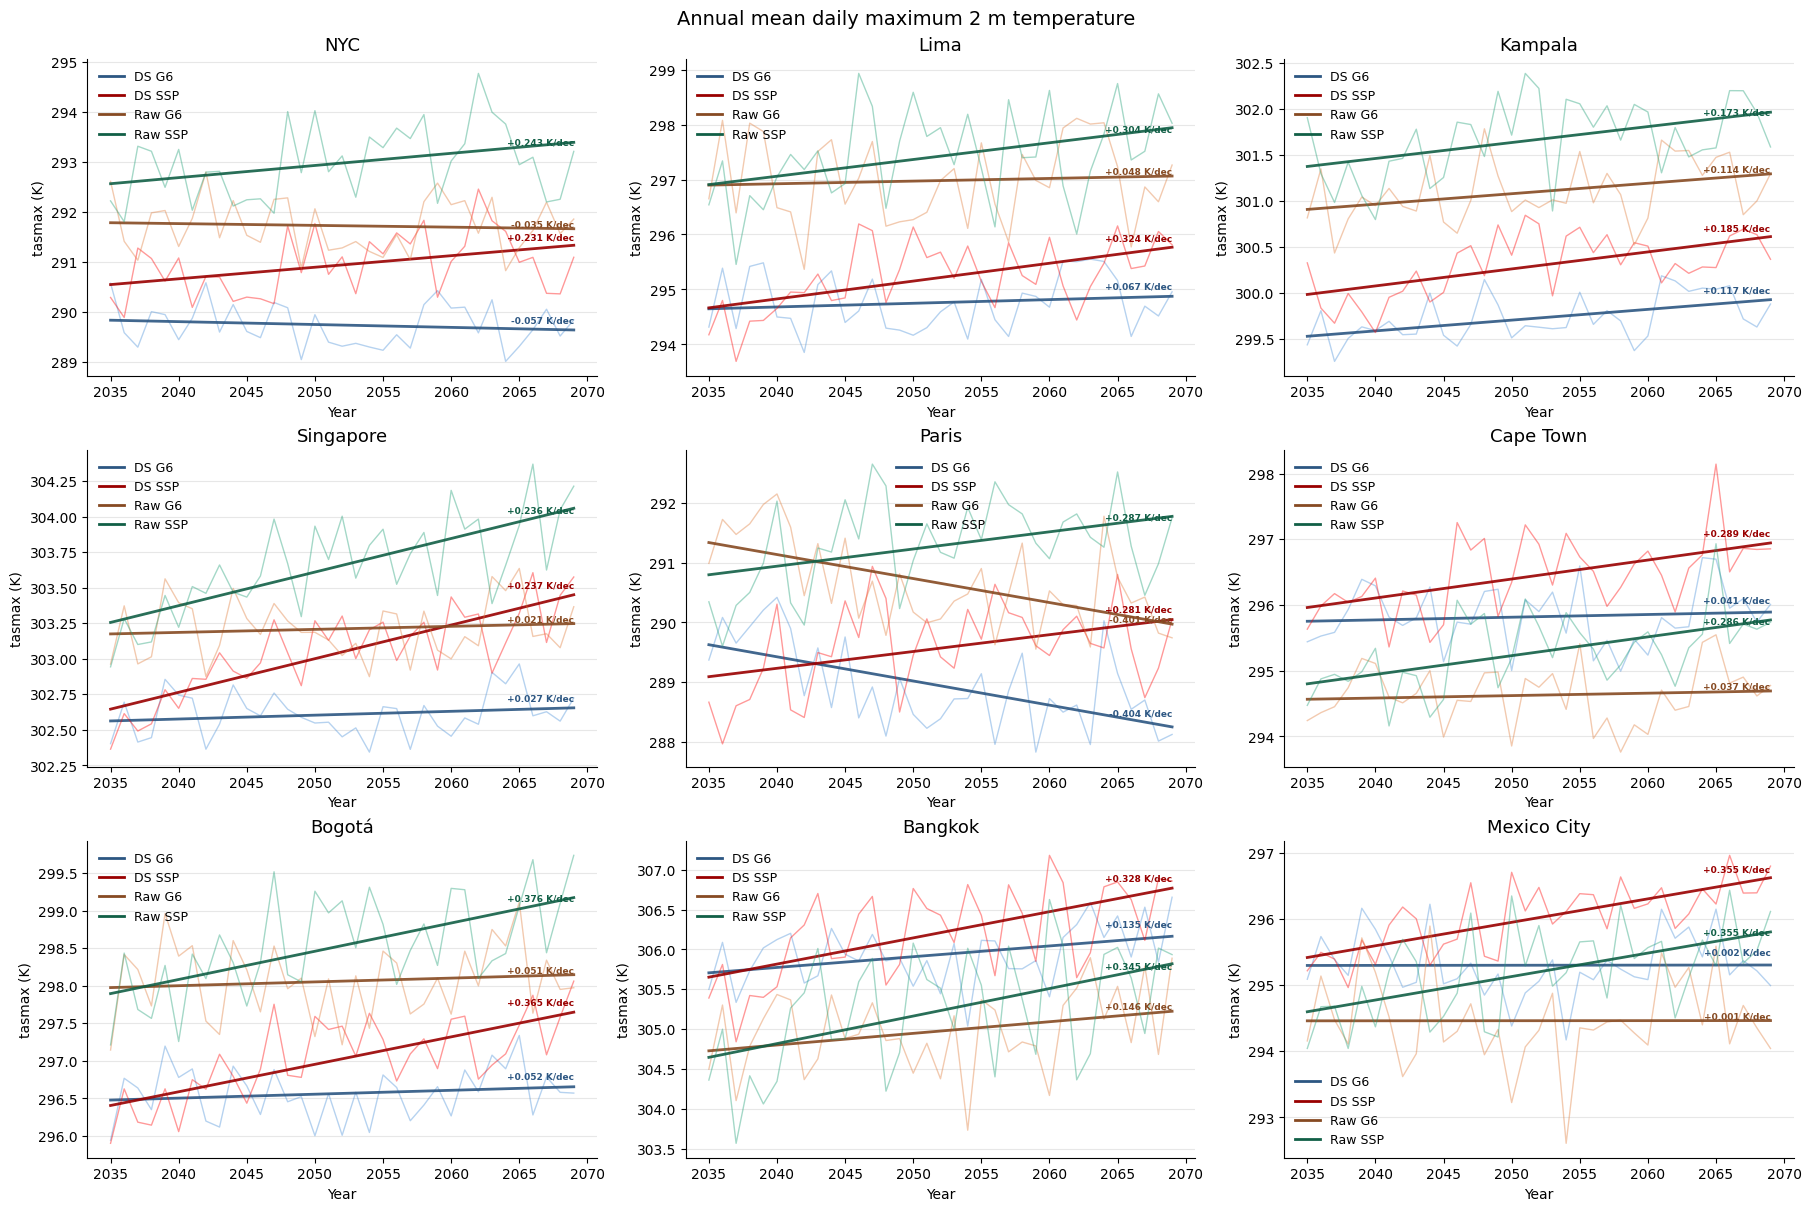

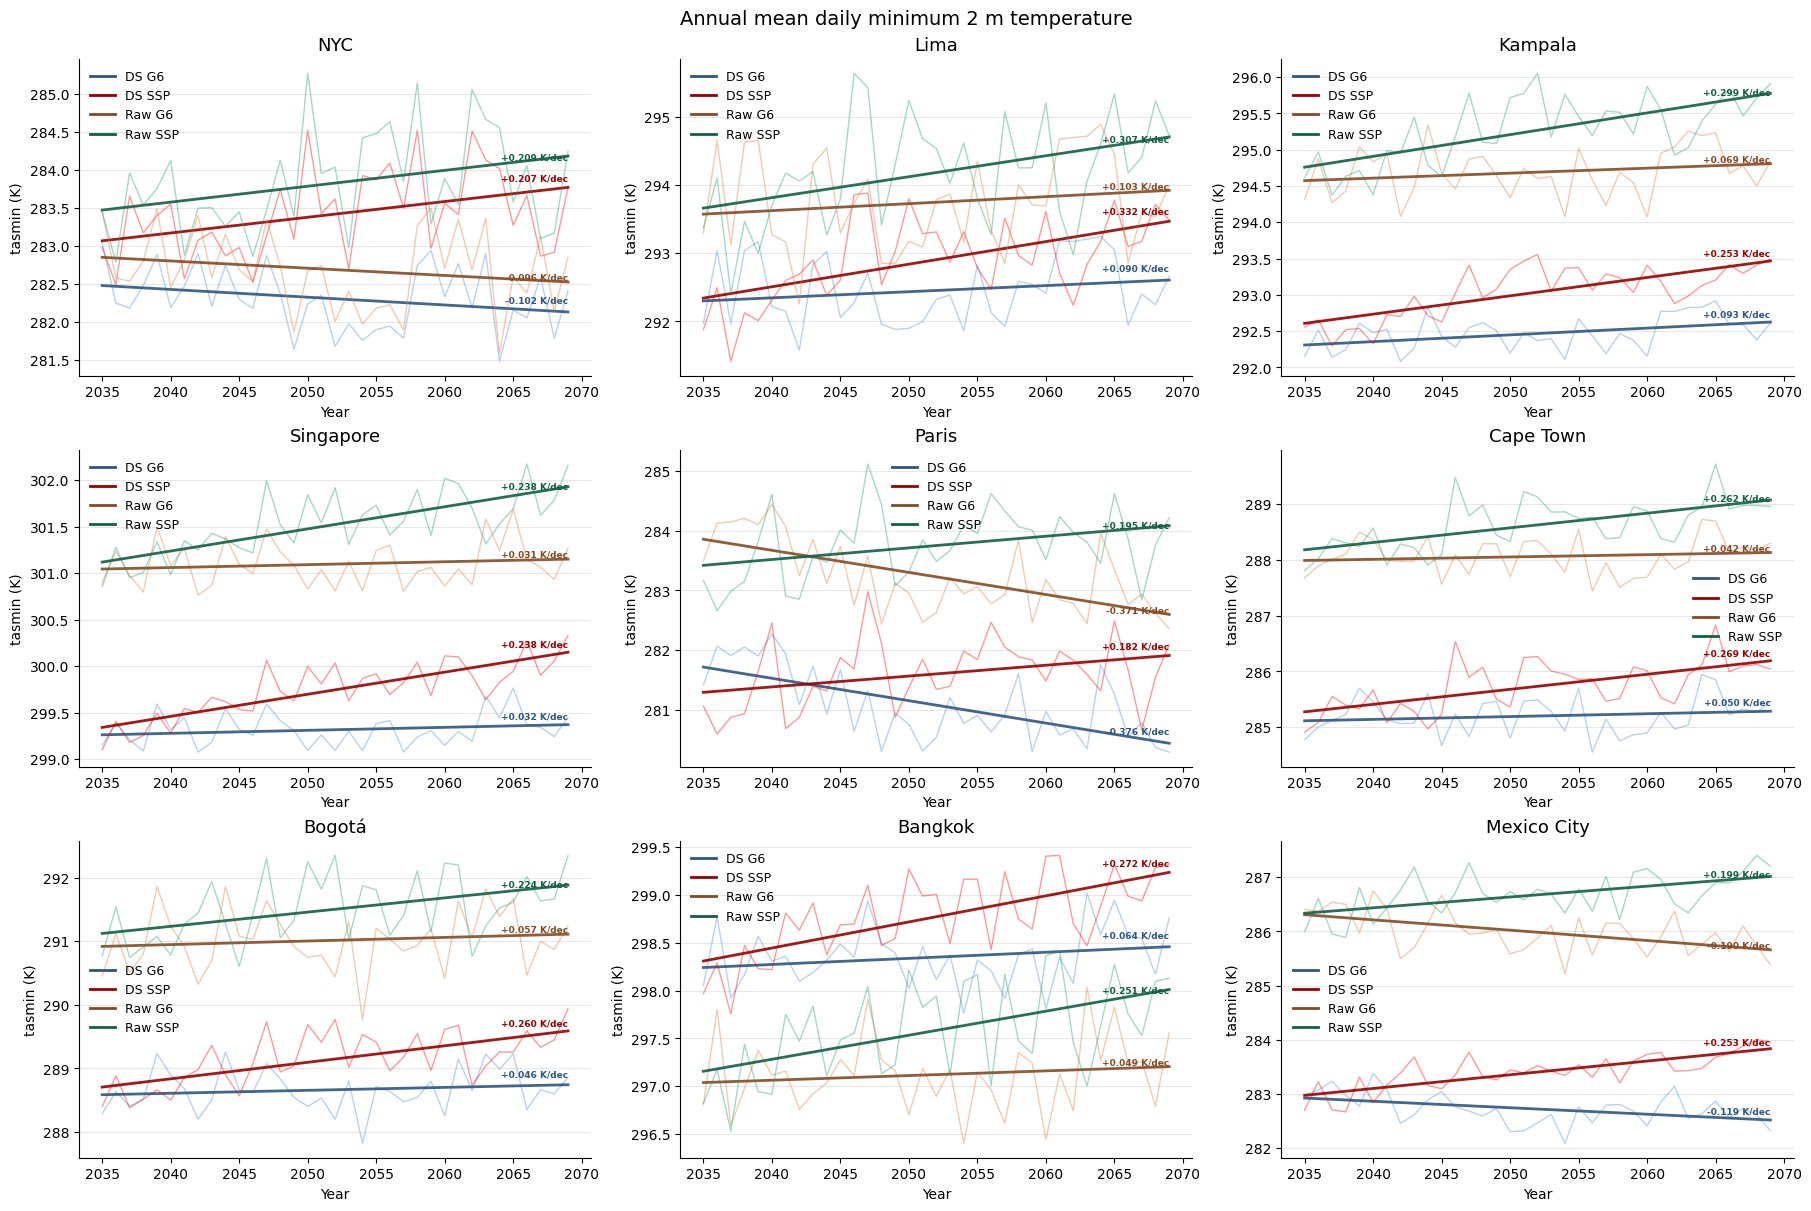

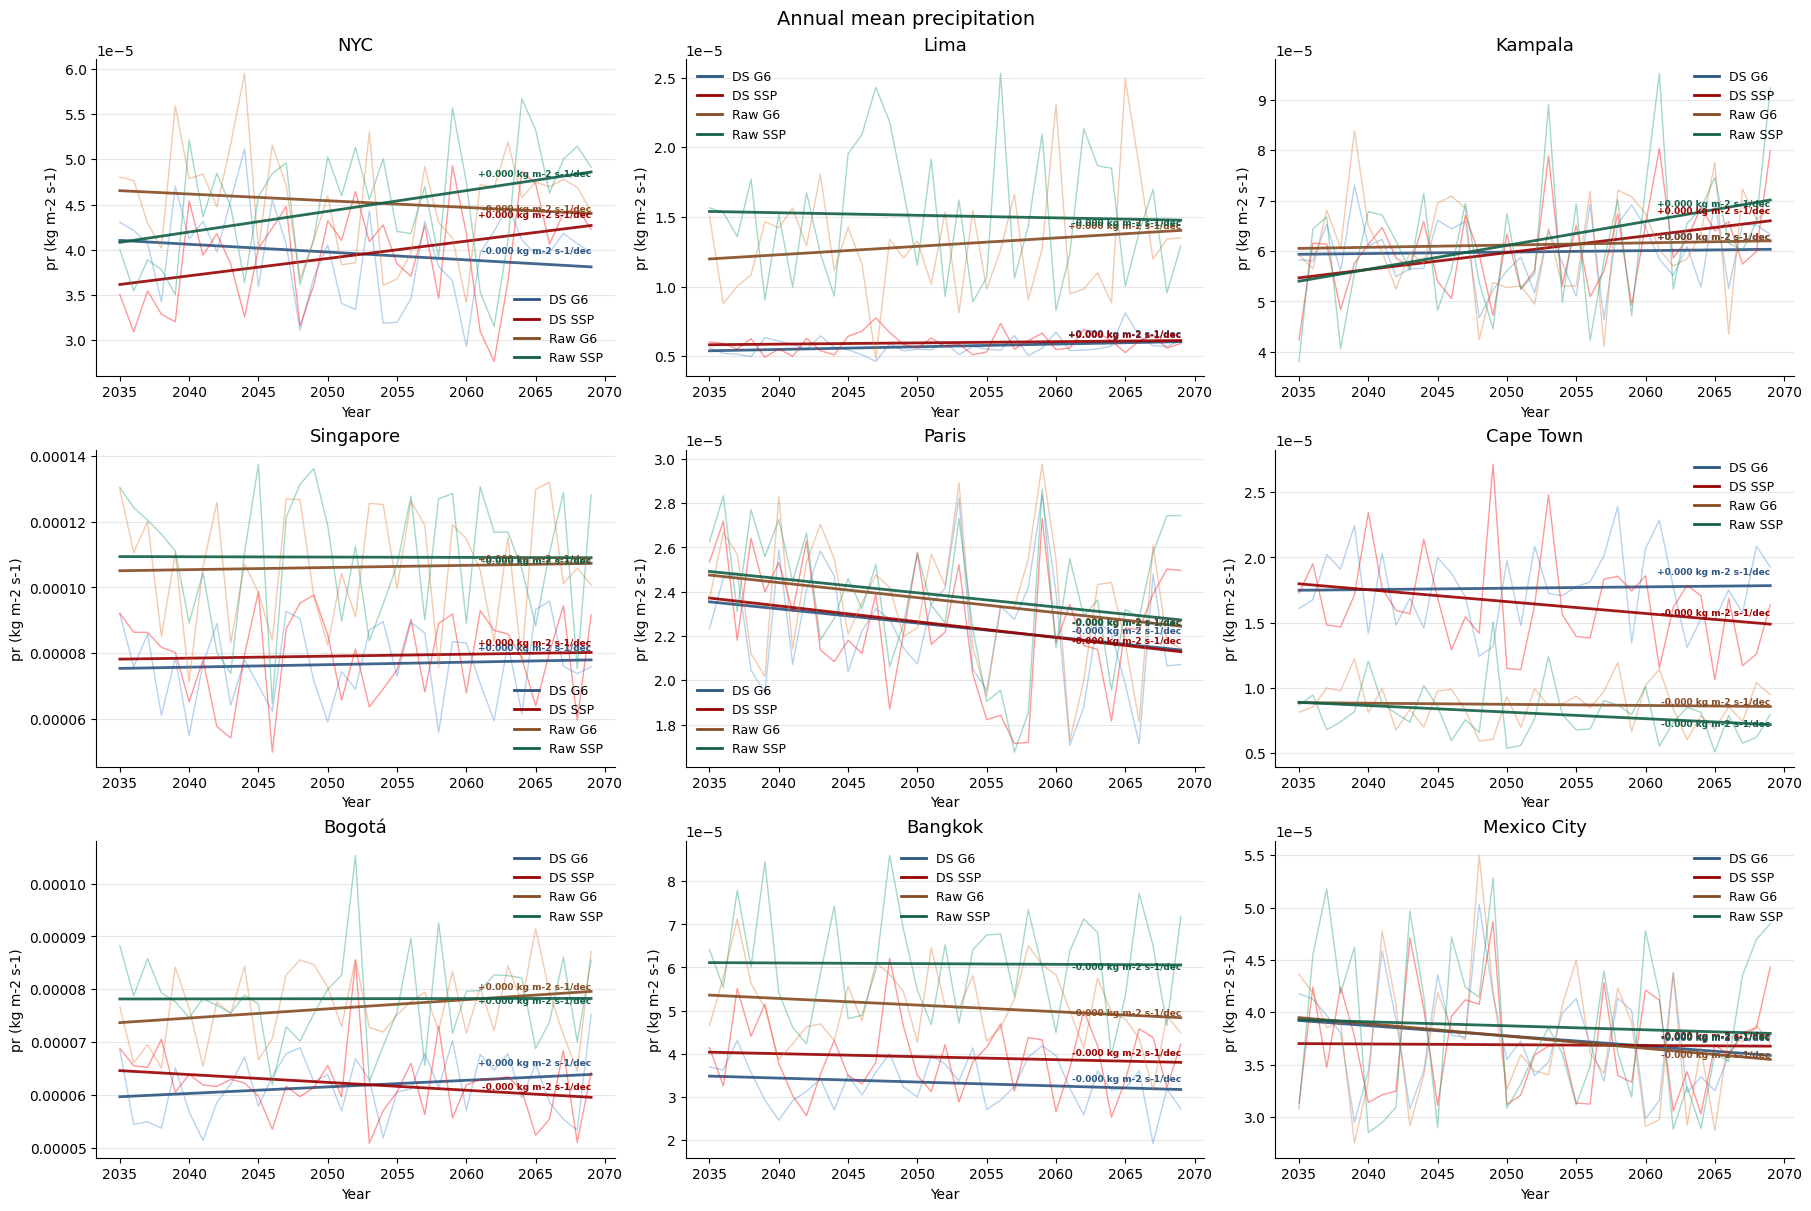

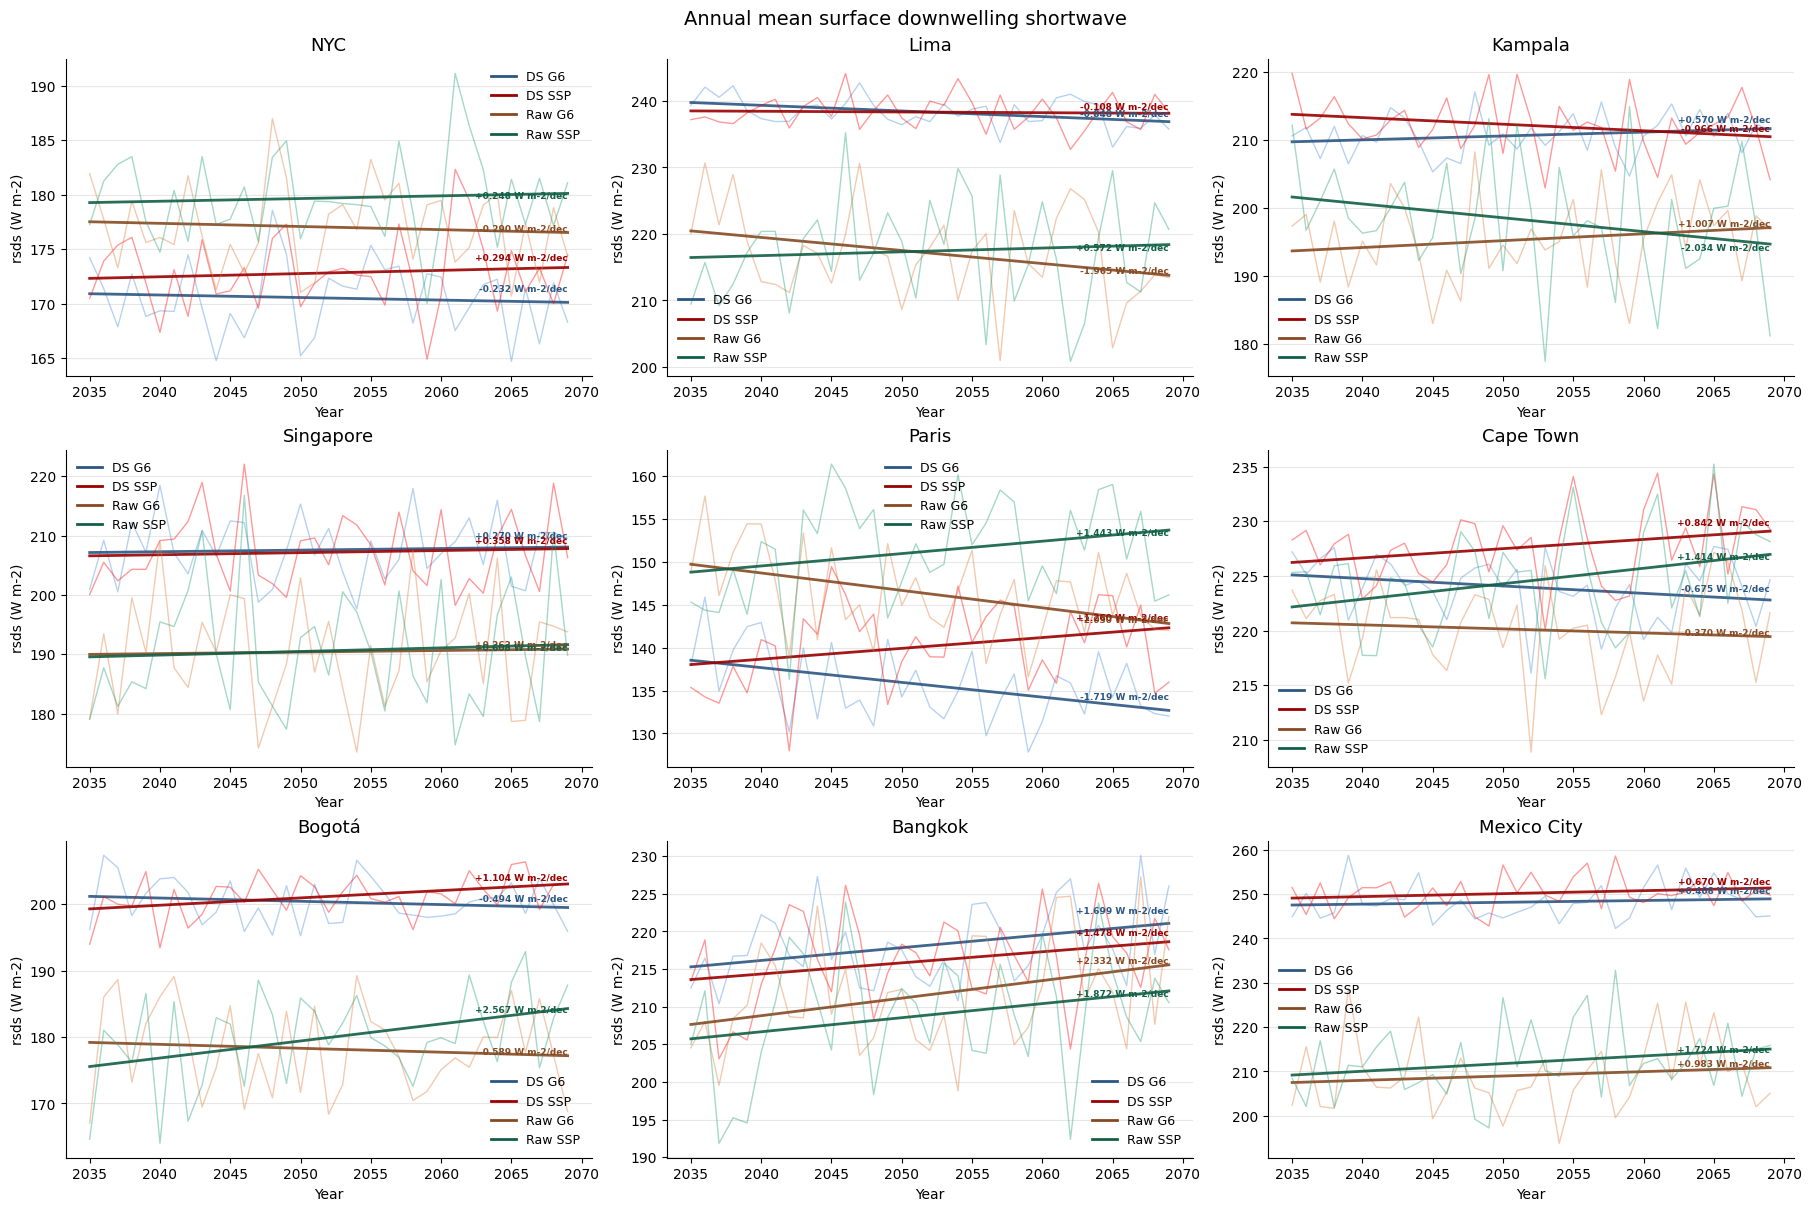

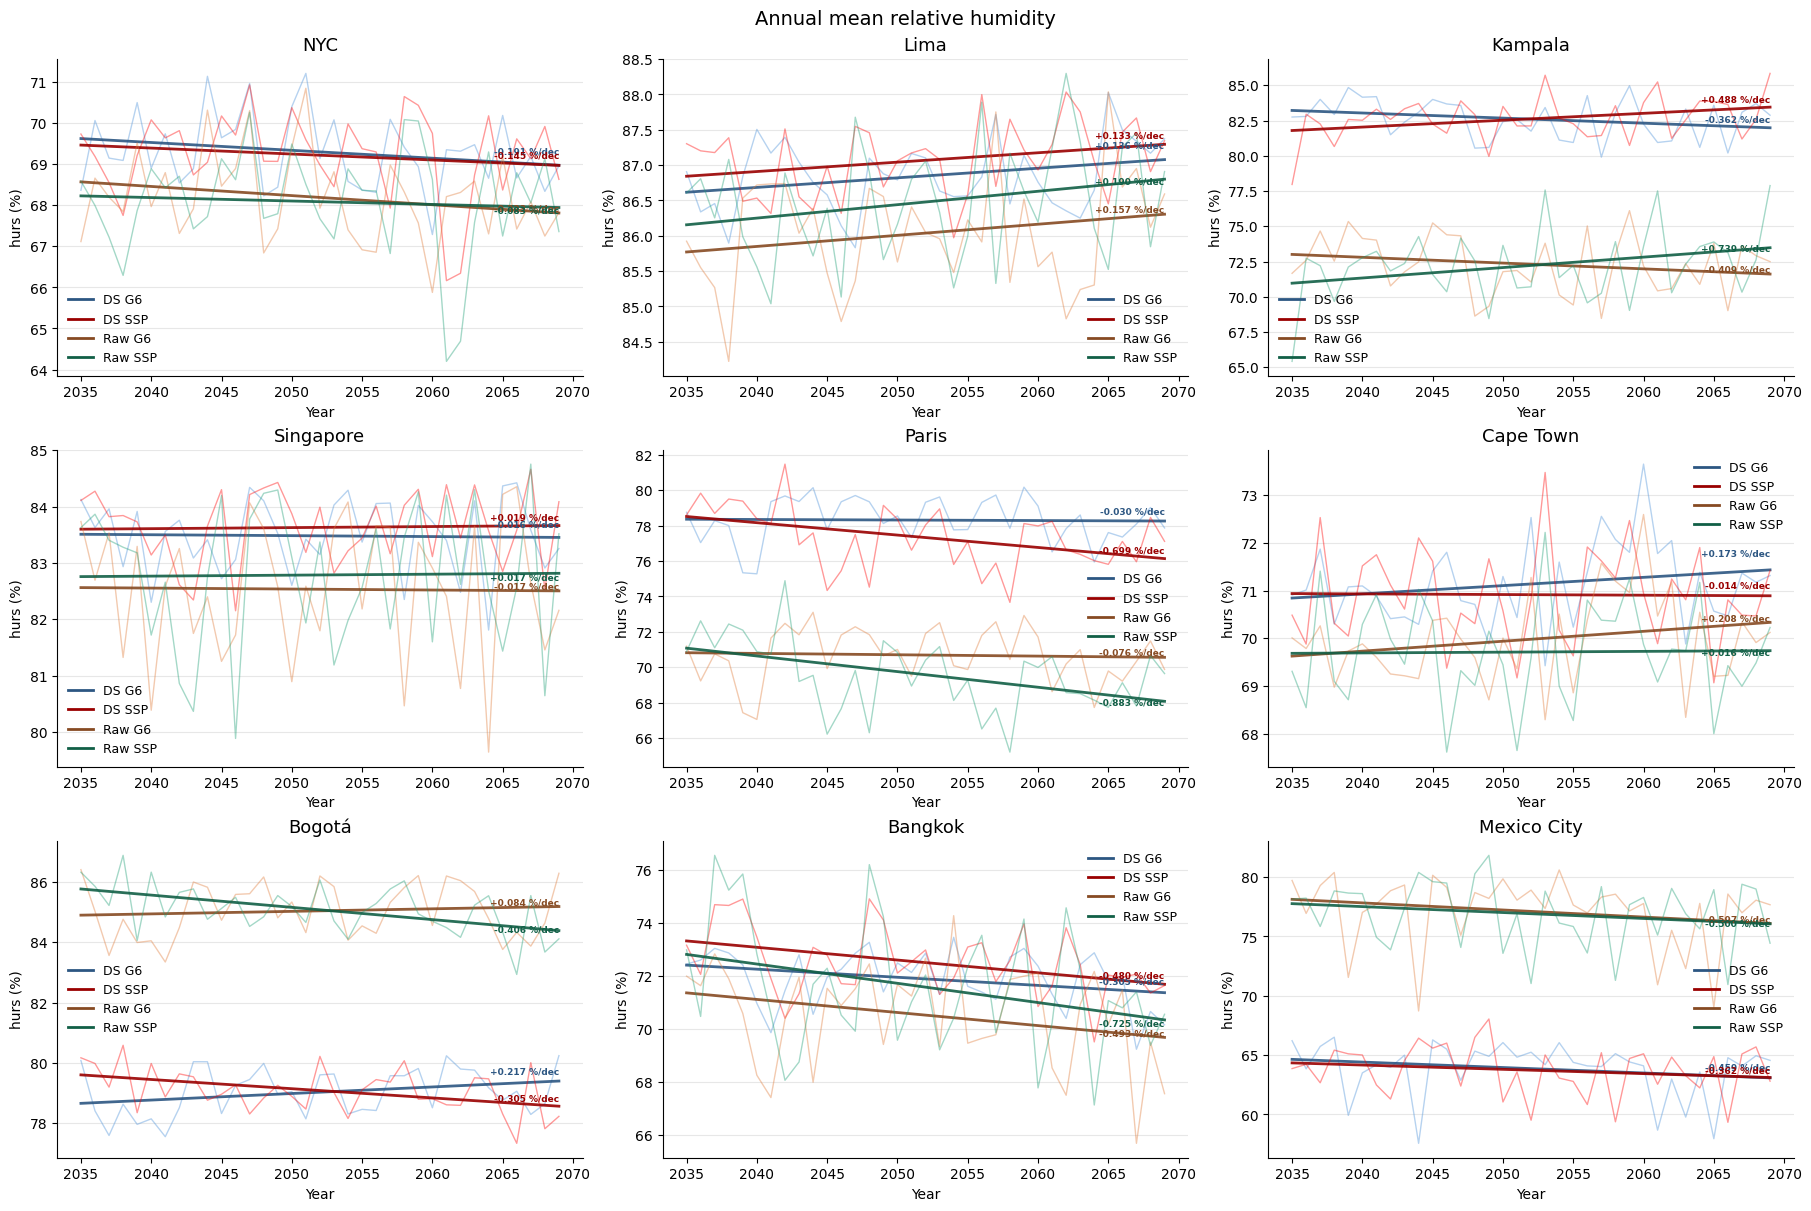

In [84]:
SOURCES = {
    "DS G6": city_g6_ds,
    "DS SSP": city_ssp_ds,
    "Raw G6": city_raw_g6,
    "Raw SSP": city_raw_ssp,
}

# materialize once, all four in a single pass
# SOURCES = dict(zip(SOURCES, dask.compute(*SOURCES.values())))

COLORS = {
    "DS G6": "#4A90D9",
    "DS SSP": "red",
    "Raw G6": "#E07B39",
    "Raw SSP": "#1D9E75",
}
SLOPE_VOFFSET = {"DS G6": 2, "DS SSP": 1, "Raw G6": 0, "Raw SSP": -1}
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]
UNIT_FALLBACK = {
    "tas": "K",
    "tasmax": "K",
    "tasmin": "K",
    "pr": "mm/day",
    "rsds": "W/m²",
    "hurs": "%",
}
VAR_TITLE = {
    "tas": "Annual mean 2 m temperature",
    "tasmax": "Annual mean daily maximum 2 m temperature",
    "tasmin": "Annual mean daily minimum 2 m temperature",
    "pr": "Annual mean precipitation",
    "rsds": "Annual mean surface downwelling shortwave",
    "hurs": "Annual mean relative humidity",
}


def darken(hex_color, factor=0.6):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r * factor, g * factor, b * factor)


city_list = list(SOURCES["DS G6"].location.values)

for var in VARIABLES:
    fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)
    axes_flat = axes.flatten()
    for i, city in enumerate(city_list):
        ax = axes_flat[i]
        handles, units = [], UNIT_FALLBACK[var]
        for src, ds in SOURCES.items():
            a = ds[var].sel(location=city)
            units = a.attrs.get("units", UNIT_FALLBACK[var])
            years = a.time.dt.year.values
            vals = a.values.astype(np.float32)

            color, dk_color = COLORS[src], darken(COLORS[src], 0.6)
            ax.plot(years, vals, color=color, lw=1, alpha=0.4)

            mask = np.isfinite(vals)
            if mask.sum() < 2:
                continue

            m, b = np.polyfit(years[mask], vals[mask], 1)
            fit_years = np.array([years[mask][0], years[mask][-1]])
            fit_vals = m * fit_years + b
            ax.plot(fit_years, fit_vals, color=dk_color, lw=2, alpha=0.9)

            yrange = np.nanmax(vals) - np.nanmin(vals)
            offset = SLOPE_VOFFSET[src] * 0.03 * (yrange or 1)
            ax.text(
                fit_years[-1],
                fit_vals[-1] + offset,
                f"{m * 10:+.3f} {units}/dec",
                color=dk_color,
                fontsize=6.5,
                ha="right",
                va="bottom",
                fontweight="bold",
            )
            handles.append(mlines.Line2D([], [], color=dk_color, lw=2, label=src))

        ax.set_title(city, fontsize=13, fontweight="500")
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel(f"{var} ({units})", fontsize=10)
        ax.legend(handles=handles, fontsize=9, frameon=False)
        ax.grid(axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle(VAR_TITLE[var], fontsize=14, fontweight="500")
    plt.show()

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Datasets (already annual means)
# -----------------------------
DATASETS = {
    "Coarse G6": city_g6_ds,
    "Coarse SSP": city_ssp_ds,
    "Raw G6": city_raw_g6,
    "Raw SSP": city_raw_ssp,
}

SRC_ORDER = ["Coarse G6", "Coarse SSP", "Raw G6", "Raw SSP"]

VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]

VAR_TITLE = {
    "tas": "Annual mean 2 m temperature",
    "tasmax": "Annual mean daily maximum 2 m temperature",
    "tasmin": "Annual mean daily minimum 2 m temperature",
    "pr": "Annual mean precipitation",
    "rsds": "Annual mean surface downwelling shortwave",
    "hurs": "Annual mean relative humidity",
}

UNIT_FALLBACK = {
    "tas": "K",
    "tasmax": "K",
    "tasmin": "K",
    "pr": "mm/day",
    "rsds": "W m$^{-2}$",
    "hurs": "%",
}

METHOD_COLOR = {
    "Coarse": "#4A90D9",
    "Raw": "#E07B39",
}

SCEN_HATCH = {
    "G6": "",
    "SSP": "///",
}


def method_of(s):
    return "Coarse" if s.startswith("Coarse") else "Raw"


def scen_of(s):
    return "G6" if "G6" in s else "SSP"


USE_PERCENT = True

cities = DATASETS[SRC_ORDER[0]].location.values.tolist()

# -----------------------------
# Calculate trends
# -----------------------------
trends = {v: {c: {} for c in cities} for v in VARIABLES}

for src in SRC_ORDER:
    ds = DATASETS[src]
    years = ds.time.dt.year.values.astype(float)

    for var in VARIABLES:
        values = ds[var].values  # (time, location)

        slopes = np.full(values.shape[1], np.nan)

        for i in range(values.shape[1]):
            y = values[:, i]

            if np.all(np.isfinite(y)):
                slope = np.polyfit(years, y, 1)[0] * 10  # per decade

                if USE_PERCENT:
                    mean = np.mean(y)
                    slope = slope / mean * 100

                slopes[i] = slope

        for city, slope in zip(cities, slopes):
            trends[var][city][src] = slope

# -----------------------------
# Plot
# -----------------------------
n_src = len(SRC_ORDER)
group_width = 0.8
bar_width = group_width / n_src

fig, axes = plt.subplots(3, 2, figsize=(20, 16), constrained_layout=True)

for ax, var in zip(axes.flat, VARIABLES):
    for j, src in enumerate(SRC_ORDER):
        x = np.arange(len(cities)) + (j - (n_src - 1) / 2) * bar_width
        y = [trends[var][city][src] for city in cities]

        ax.bar(
            x,
            y,
            width=bar_width,
            color=METHOD_COLOR[method_of(src)],
            hatch=SCEN_HATCH[scen_of(src)],
            edgecolor="white",
            linewidth=0.6,
        )

    unit = "%/decade" if USE_PERCENT else f"{UNIT_FALLBACK[var]}/decade"

    ax.axhline(0, color="0.3", lw=0.8)
    ax.set_xticks(np.arange(len(cities)))
    ax.set_xticklabels(cities, rotation=45, ha="right")
    ax.set_title(VAR_TITLE[var], fontsize=12)
    ax.set_ylabel(f"Trend ({unit})")
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    mpatches.Patch(color=METHOD_COLOR["Coarse"], label="DS Coarsened"),
    mpatches.Patch(color=METHOD_COLOR["Raw"], label="Raw GCM"),
    mpatches.Patch(facecolor="lightgray", edgecolor="black", hatch="", label="G6"),
    mpatches.Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="SSP"),
]

fig.legend(
    handles=legend_handles,
    ncol=4,
    loc="upper center",
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    f"City trends ({'%/decade' if USE_PERCENT else 'units/decade'})",
    fontsize=15,
)

plt.show()